# Linear and Multiple Linear Regression

In this lab you will practice performing linear and multiple regression. To begin, import the following libraries:

In [3]:
# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Then, we'll import the dataset: 

In [47]:
# Reading the dataset
df = pd.read_parquet('final_dataset.parquet')

In this part, you will generate a boxplot and remove outliers using IQR method. To begin, replace NaN values with 0 and filter the dataset to use `date`, `max_temp`, and `sm_pca`. After cleaning and filtering your dataset, generate the boxplot and remove outliers using IQR.

In [48]:
df = df[['date', 'max_temp', 'sm_pca']]
df = df.fillna(value=0)
#print(df.head())
cols = ['max_temp', 'sm_pca'] # one or more
#print(df['max_temp'].mean())
for col in cols:
    Q1 = df[[col]].quantile(0.25)
    Q3 = df[[col]].quantile(0.75)
    IQR = Q3 - Q1
    #print(IQR)
    df = df[~((df[[col]] <= (Q1 - 1.5 * IQR)) | (df[[col]] >= (Q3 + 1.5 * IQR))).any(axis=1)]
#print(df['max_temp'].mean())
df.head()
# your code here
#raise NotImplementedError

,date,max_temp,sm_pca
13,2010-02-27,50,2.043029
14,2010-02-28,44,1.830903
15,2010-03-01,43,1.610450
16,2010-03-02,55,1.488830
17,2010-03-03,61,1.377398


In [49]:
assert (df.shape == (4632, 3), "Check that your dataframe is filtered correctly.")
assert (np.isclose(df['max_temp'].mean(), 72.173143)), "Check that you have removed outliers correctly for max_temp."
assert (np.isclose(df['sm_pca'].mean(), -0.258722)), "Check that you have removed outliers correctly for sm_pca."
assert (np.isclose(df['max_temp'].min(), 11.000000)), "Check that you have removed outliers correctly for max_temp."
assert (np.isclose(df['sm_pca'].max(), 2.233630)), "Check that you have removed outliers correctly for sm_pca."

Next, we'll split the data into training and testing sets before performing a linear regression using `LinearRegression()` and fitting the training data. Remember to reshape your data. 

After performing the linear regression, you should generate a graph similar to the following: 

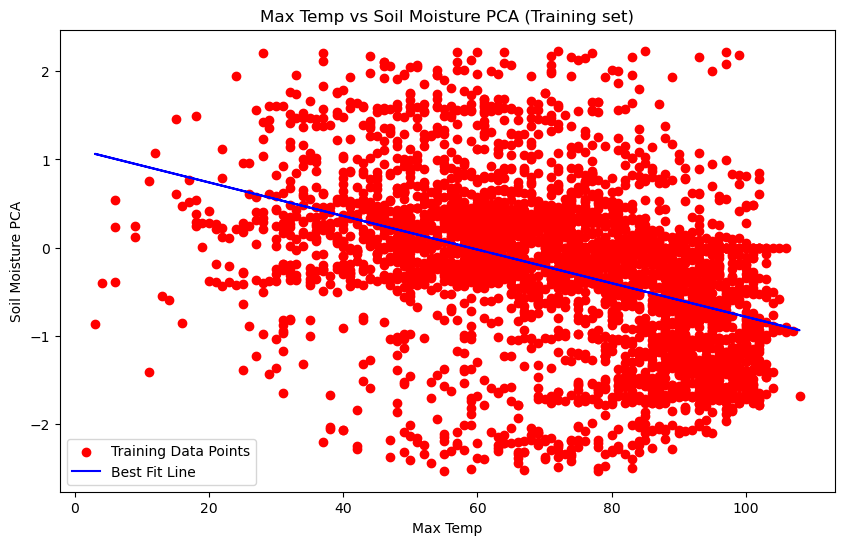


In [54]:
# Splitting data into training and test set using sklearn
X_train, X_test, y_train, y_test = train_test_split(df['max_temp'], df['sm_pca'], test_size=0.25, random_state=0)

# Looking at training data and test data

display(X_train.head())
display(y_train.head())
display(X_test.head())
display(y_test.head())

2803    66
1495    78
1973    98
1159    60
3771    98
Name: max_temp, dtype: int64

2803    1.192699
1495    0.408074
1973   -0.500562
1159   -0.393938
3771   -1.645886
Name: sm_pca, dtype: float64

394     71
593     68
1873    67
3975    44
3333    83
Name: max_temp, dtype: int64

394    -0.289785
593    -0.749500
1873    0.309108
3975    0.020986
3333   -1.529026
Name: sm_pca, dtype: float64

In [55]:
# your code here
#raise NotImplementedError
X_train = X_train.values.reshape(-1,1)
model = LinearRegression().fit(X_train, y_train)
model.score(X_train, y_train)

0.17656709200883003

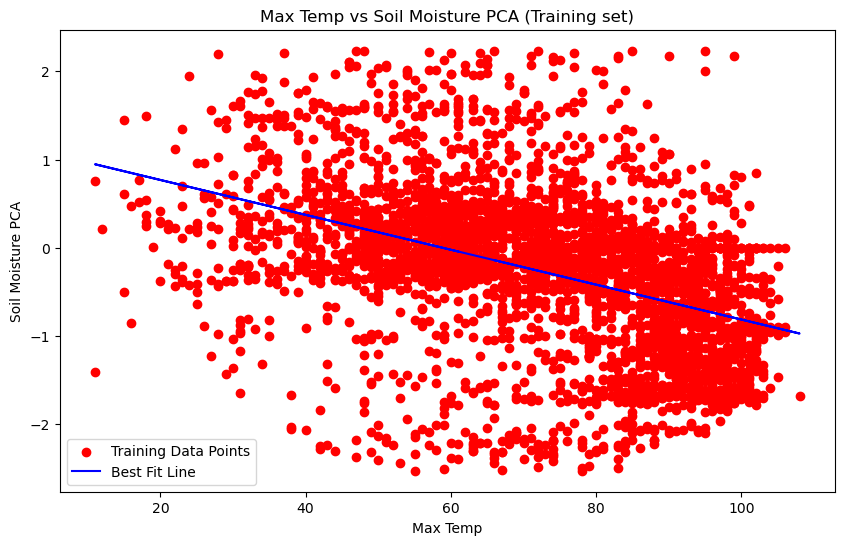

In [56]:
# Visualizing the training set results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='red')

# Plotting the best fit line
plt.plot(X_train, model.predict(X_train), color='blue')
plt.title('Max Temp vs Soil Moisture PCA (Training set)')
plt.xlabel('Max Temp')
plt.ylabel('Soil Moisture PCA')
plt.legend(['Training Data Points', 'Best Fit Line'])
plt.show()

Finally, you will calculate the mean squared error (MSE) and the R2 score for both the training and test data. 

In [59]:
# your code here
#raise NotImplementedError

y_pred = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_pred) 
r2_train = r2_score(y_train, y_pred)

y_pred = model.predict(X_test.values.reshape(-1,1))
mse_test = mean_squared_error(y_test, y_pred) 
r2_test = r2_score(y_test, y_pred)


print(f'Mean Squared Error for Training data: {mse_train}')
print(f'R2 Score for Training data: {r2_train}')
print(f'Mean Squared Error for Test data: {mse_test}')
print(f'R2 Score for Test data: {r2_test}')

Mean Squared Error for Training data: 0.7083519834616381
R2 Score for Training data: 0.17656709200883003
Mean Squared Error for Test data: 0.8355896065171731
R2 Score for Test data: 0.1283955991150405
